In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
X = 6 * np.random.rand(100,1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100,1)

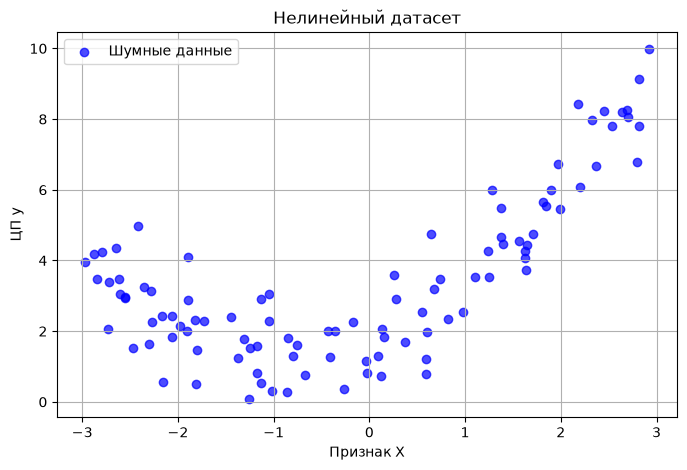

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color = 'blue', alpha=0.7, label = 'Шумные данные')
plt.title('Нелинейный датасет')
plt.xlabel('Признак X')
plt.ylabel('ЦП y')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [5]:
lin_reg = LinearRegression()
lin_reg.fit(X,y)

poly_features = PolynomialFeatures(degree = 2, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 2)","[[0.93,0.56]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.78]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[26.82,17.58]"


In [6]:
X_new = np.linspace(-3, 3,100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)

y_new_lin = lin_reg.predict(X_new)
y_new_poly = poly_reg.predict(X_new_poly)

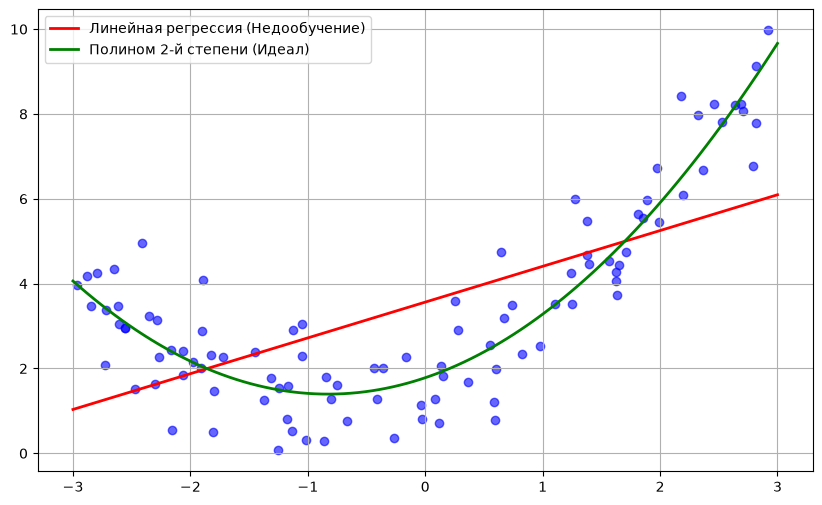

Истинные коэффициенты формулы: 0.5, 1.0, 2.0
Предсказанные веса полинома: 0.56, 0.93, а свободный член: 1.78


In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6)
plt.plot(X_new, y_new_lin, "r-", linewidth=2, label="Линейная регрессия (Недообучение)")
plt.plot(X_new, y_new_poly, "g-", linewidth=2, label="Полином 2-й степени (Идеал)")
plt.legend()
plt.grid(True)
plt.show()

print("Истинные коэффициенты формулы: 0.5, 1.0, 2.0")
print(f"Предсказанные веса полинома: {poly_reg.coef_[0][1]:.2f}, {poly_reg.coef_[0][0]:.2f}, а свободный член: {poly_reg.intercept_[0]:.2f}")

Кривые обучения для ЛР:


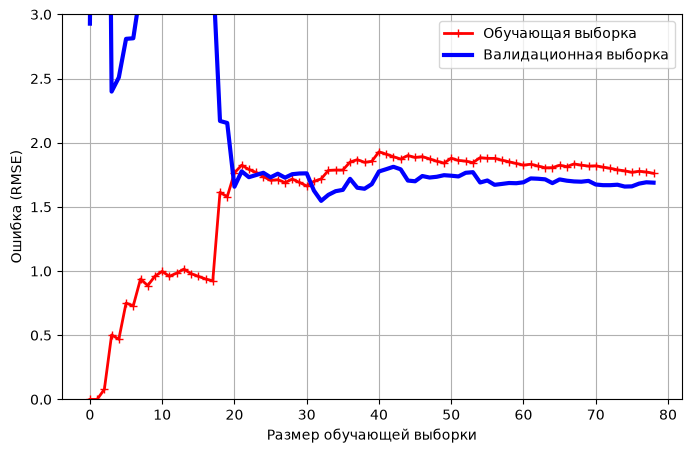

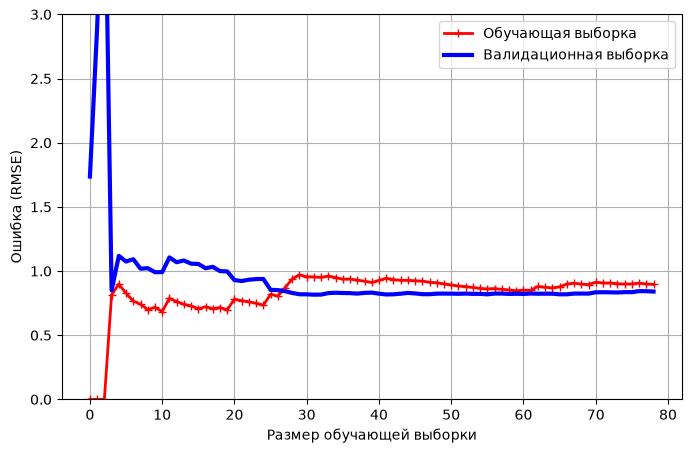

In [23]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []

    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))

    plt.figure(figsize=(8, 5))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="Обучающая выборка")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Валидационная выборка")
    plt.legend()
    plt.xlabel("Размер обучающей выборки")
    plt.ylabel("Ошибка (RMSE)")
    plt.grid(True)
    plt.ylim(0, 3)

print('Кривые обучения для ЛР:')
plot_learning_curves(lin_reg, X, y)
plt.show()

plot_learning_curves(poly_reg, X_poly, y)
plt.show()

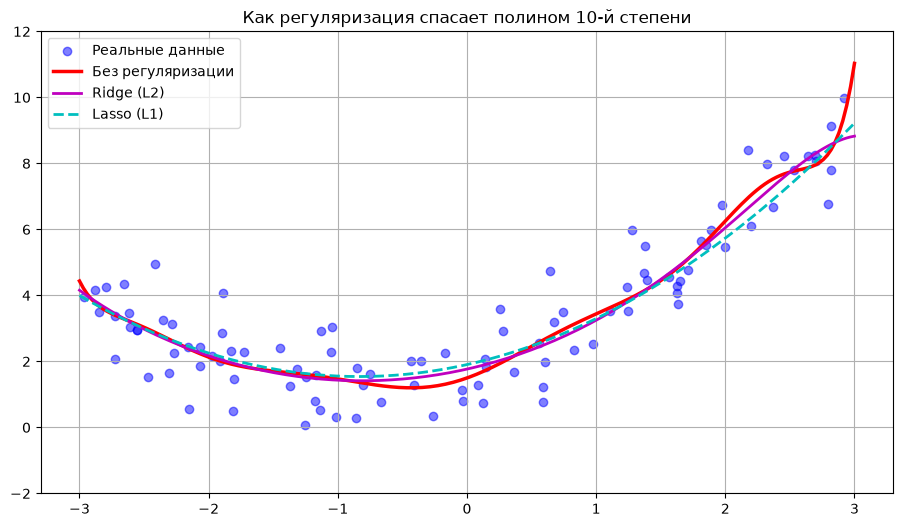

--- Веса признаков в Lasso ---
Степень X^1: вес = 1.5463
Степень X^2: вес = 1.3958
Степень X^3: вес = 0.0000
Степень X^4: вес = 0.0000
Степень X^5: вес = 0.0000
Степень X^6: вес = 0.0000
Степень X^7: вес = 0.0000
Степень X^8: вес = 0.0000
Степень X^9: вес = 0.0000
Степень X^10: вес = 0.0000


In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

no_reg = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("std_scaler", StandardScaler()),
    ("reg_model", LinearRegression())
])
no_reg.fit(X, y)

ridge_reg = model_pipeline(Ridge, alpha_value=1.0)
ridge_reg.fit(X, y)

lasso_reg = model_pipeline(Lasso, alpha_value=0.1)
lasso_reg.fit(X, y)

X_new = np.linspace(-3, 3, 200).reshape(200, 1) 
y_new_no_reg = no_reg.predict(X_new)
y_new_ridge = ridge_reg.predict(X_new)
y_new_lasso = lasso_reg.predict(X_new)

plt.figure(figsize=(11, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label="Реальные данные")

plt.plot(X_new, y_new_no_reg, "r-", linewidth=2.5, label="Без регуляризации")
plt.plot(X_new, y_new_ridge, "m-", linewidth=2, label="Ridge (L2)")
plt.plot(X_new, y_new_lasso, "c--", linewidth=2, label="Lasso (L1)")

plt.title("Как регуляризация спасает полином 10-й степени")
plt.ylim([-2, 12]) # Ограничим график по высоте, иначе красная линия улетит в космос
plt.legend()
plt.grid(True)
plt.show()

weights = lasso_reg.named_steps["reg_model"].coef_
print("--- Веса признаков в Lasso ---")
for i, w in enumerate(weights, 1):
    print(f"Степень X^{i}: вес = {w:.4f}")


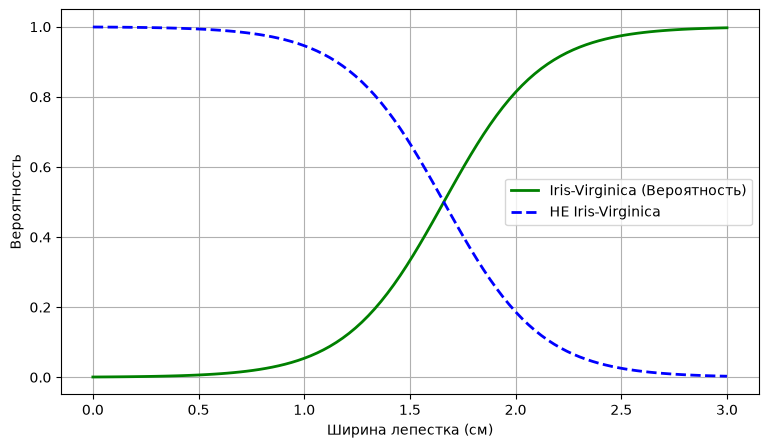

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
X_iris = iris["data"][:, 3:] 
y_iris = (iris["target"] == 2).astype(int) 

# работает как обычная регрессия, но потом пропускает резульатат через Сигмоиду
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_iris, y_iris)

X_new_iris = np.linspace(0, 3, 100).reshape(100, 1)
y_proba = log_reg.predict_proba(X_new_iris)

plt.figure(figsize=(9, 5))
plt.plot(X_new_iris, y_proba[:, 1], "g-", linewidth=2, label="Iris-Virginica (Вероятность)")
plt.plot(X_new_iris, y_proba[:, 0], "b--", linewidth=2, label="НЕ Iris-Virginica")
plt.xlabel("Ширина лепестка (см)")
plt.ylabel("Вероятность")
plt.legend()
plt.grid(True)
plt.show()
